# Module 01: Mathematical Foundations & Exploratory Data Analysis (EDA)


## Module outline

* **Step 1: Descriptive Statistics & Central Tendency**
  * What is data? Quantitative (Discrete, Continuous) vs. Qualitative (Nominal, Ordinal).
  * Central Tendency: Mean, Median, Mode, Trimmed Mean, and geometric/harmonic means.
  * Measures of Dispersion: Range, Variance, Standard Deviation, Interquartile Range (IQR), Mean Absolute Deviation (MAD), and Coefficient of Variation.
  * Percentiles, Quartiles, Deciles, and the 5-Number Summary.
* **Step 2: Probability Distributions & Shape Metrics**
  * Probability Mass Function (PMF) vs. Probability Density Function (PDF) vs. Cumulative Distribution Function (CDF).
  * Standard Distributions: Normal/Gaussian (Empirical 68-95-99.7 Rule), Log-Normal, Uniform, Binomial, Poisson, Exponential, and Bernoulli.
  * Distribution Shape: Skewness (Pearson's coefficient of skewness) and Kurtosis (Mesokurtic, Leptokurtic, Platykurtic).
  * QQ-Plots (Quantile-Quantile) for distribution verification.
* **Step 3: Covariance, Correlation, & Association**
  * Covariance: Mathematical formulation, directional dependency, and scale limitation.
  * Pearson Product-Moment Correlation ($r$): Linear relationship measurement $[-1, 1]$.
  * Spearman Rank Correlation: Assessing non-linear monotonic relationships.
  * Kendall's Tau: Rank correlation for small datasets with tied ranks.
  * Categorical Association: Chi-Square Test of Independence, Cramér's V, and Mutual Information (information gain).
* **Step 4: Advanced Statistical Inference & Hypothesis Testing**
  * Core Concepts: Null Hypothesis ($H_0$) vs. Alternative Hypothesis ($H_1$), Significance Level ($\alpha$), p-values, Critical Regions, and Power of a Test ($1 - \beta$).
  * Decision Errors: Type I Error (False Positive) and Type II Error (False Negative).
  * Parametric Tests: One/Two-Sample t-tests, Paired t-tests, Z-tests, and F-tests.
  * ANOVA (Analysis of Variance): One-Way and Two-Way ANOVA for comparing multiple groups.
  * Non-Parametric Tests: Mann-Whitney U, Wilcoxon Signed-Rank, Kruskal-Wallis, and Kolmogorov-Smirnov (KS) tests.
  * Multicollinearity: Diagnostics using Correlation Matrices, Eigenvalues, and Variance Inflation Factor (VIF).


## Example Dataset


In [1]:
import pandas as pd
from IPython.display import display

# Let's define our exact 10-employee dataset in Python to display it cleanly
data = {
    'Employee ID': ['Emp 1', 'Emp 2', 'Emp 3', 'Emp 4', 'Emp 5', 'Emp 6', 'Emp 7', 'Emp 8', 'Emp 9', 'Emp 10'],
    'Department': ['Sales', 'R&D', 'HR', 'R&D', 'Sales', 'R&D', 'HR', 'Sales', 'R&D', 'Sales'],
    'Performance Rating': ['Low', 'Medium', 'Medium', 'High', 'High', 'Low', 'High', 'Medium', 'High', 'Medium'],
    'Years at Company': [1, 3, 2, 5, 4, 1, 8, 3, 10, 3],
    'Monthly Salary': [3000, 4500, 4000, 6000, 5500, 3200, 7000, 4800, 12000, 5000],
    'Attrition (Left?)': ['Yes (1)', 'No (0)', 'No (0)', 'No (0)', 'No (0)', 'Yes (1)', 'No (0)', 'No (0)', 'No (0)', 'Yes (1)']
}

df = pd.DataFrame(data)
display(df)



Matplotlib is building the font cache; this may take a moment.


,Employee ID,Department,Performance Rating,Years at Company,Monthly Salary,Attrition (Left?)
0,Emp 1,Sales,Low,1,3000,Yes (1)
1,Emp 2,R&D,Medium,3,4500,No (0)
2,Emp 3,HR,Medium,2,4000,No (0)
3,Emp 4,R&D,High,5,6000,No (0)
4,Emp 5,Sales,High,4,5500,No (0)
5,Emp 6,R&D,Low,1,3200,Yes (1)
6,Emp 7,HR,High,8,7000,No (0)
7,Emp 8,Sales,Medium,3,4800,No (0)
8,Emp 9,R&D,High,10,12000,No (0)
9,Emp 10,Sales,Medium,3,5000,Yes (1)


### Module 1: Step 1 — Qualitative Data (Nominal vs. Ordinal)
**Qualitative data** describes categories or labels rather than measured amounts.

Using our **10-Employee Dataset** above, let's look at how we classify Qualitative (categorical) variables:

1. **Nominal (No Order / No Rank)**
   * **Definition:** Data grouped into named categories with no natural order or ranking.
   * **Where we use it:** Categories such as departments, blood groups, or cities.
   * **Why we use it:** To group records and compare them, such as counting employees in each department.
   * **In our Dataset:** The `Department` column.
     * *Values:* `Sales`, `R&D`, `HR`.
     * *Why?* Sales is not mathematically "higher" or "greater" than HR or R&D. They are simply different group names.

2. **Ordinal (Ordered / Ranked)**
   * **Definition:** Data grouped into categories that have a meaningful order, but whose gaps are not measured.
   * **Where we use it:** Performance ratings, satisfaction levels, or education levels.
   * **Why we use it:** To compare levels, such as Low, Medium, and High, without assuming equal gaps between them.
   * **In our Dataset:** The `Performance Rating` column.
     * *Values:* `Low`, `Medium`, `High`.
     * *Why?* There is a clear progression: $\text{Low} < \text{Medium} < \text{High}$. We know Medium is better than Low, even if we cannot calculate "Medium minus Low" as a precise number.

### Module 1: Step 1 — Quantitative Data (Discrete vs. Continuous)
**Quantitative data** records numerical counts or measurements.

Let's classify the numerical columns of our **10-Employee Dataset**:

1. **Discrete (Countable Values)**
   * **Definition:** Numerical data with separate, countable possible values, such as the number of employees.
   * **Where we use it:** Counts of employees, purchases, or completed years of service.
   * **Why we use it:** To record how many items or completed units there are.
   * **In our Dataset:** The `Years at Company` column.
     * *Values:* `1, 3, 2, 5, 4, 1, 8, 3, 10, 3`.
     * *Why?* This column records whole years, so its recorded values are discrete. Actual time at a company can include fractions, such as 2.5 years, and is continuous. The number of employees is a clearer example of a count.

2. **Continuous (Measurable Decimals)**
   * **Definition:** Numerical data modeled as taking any value within a range, including values between whole numbers.
   * **Where we use it:** Measurements such as height, weight, or elapsed time; salary is often treated this way in analysis.
   * **Why we use it:** To describe measured amounts without restricting them to whole units.
   * **In our Dataset:** The `Monthly Salary` column.
     * *Values:* `$3,000, $4,500, $4,000, $6,000, $5,500, $3,200, $7,000, $4,800, $12,000, $5,000`.
     * *Why?* Salary can include cents, such as `$4,500.57`, and is often treated as continuous for analysis. Strictly, payments in fixed cent increments are discrete; height or elapsed time are clearer continuous examples.

### Module 1: Step 1 — Central Tendency (Calculated step-by-step)
**Central tendency** means describing the center or typical value of a dataset.

Let's find the "center" of our **10-Employee Dataset** using different mathematical methods:

Our target column (`Monthly Salary`):
`$3,000, $3,200, $4,000, $4,500, $4,800, $5,000, $5,500, $6,000, $7,000, $12,000` *(sorted from smallest to largest)*

1. **Mean (Arithmetic Average)**
   * **Definition:** An average found by sharing the total equally among all observations.
   * **Where we use it:** Average salaries, marks, or daily sales.
   * **Why we use it:** To summarize the overall level using every value; unusually large or small values can pull it up or down.
   * **Formula:** $\text{Sum of all salaries} / \text{Total employees}$
   * **Calculation:**
     $$\text{Sum} = 3000 + 3200 + 4000 + 4500 + 4800 + 5000 + 5500 + 6000 + 7000 + 12000 = 55,000$$
     $$\text{Mean} = \frac{55,000}{10} = \mathbf{\$5,500}$$
   * *Note:* Notice how our single high outlier (**Emp 9** earning \$12,000) pulled the mean up to \$5,500. 6 out of 10 employees actually earn *less* than this average!

2. **Median (Physical Middle)**
   * **Definition:** The middle value after sorting the data; with an even count, average the two middle values.
   * **Where we use it:** Typical salaries or house prices when a few values are unusually high or low.
   * **Why we use it:** To describe the center without letting extreme values pull it as strongly as they pull the mean.
   * **Formula:** The middle value of the sorted list. Since we have an even number of values (10), we average the two middle values (5th and 6th numbers).
   * **Sorted values:** `$3,000, $3,200, $4,000, $4,500,` **[\$4,800, \$5,000]**, `$5,500, $6,000, $7,000, $12,000`
   * **Calculation:**
     $$\text{Median} = \frac{4,800 + 5,000}{2} = \mathbf{\$4,900}$$
   * *Note:* Raising the highest salary from \$12,000 to \$50,000 would leave the two middle values, and therefore the median, unchanged.

3. **Mode (Most Frequent)**
   * **Definition:** The value or category that appears most often; more than one can tie for first place.
   * **Where we use it:** The most common rating, product size, or department.
   * **Why we use it:** To identify the most frequent choice, including categories that cannot be averaged.
   * **Calculation:** Look at the `Performance Rating` column: `[Low, Medium, Medium, High, High, Low, High, Medium, High, Medium]`
     * `Low` appears 2 times.
     * `High` appears 4 times.
     * `Medium` appears 4 times.
   * **Result:** This dataset is **bimodal** with two Modes: **Medium** and **High**.

4. **Trimmed Mean (Outlier Resistant)**
   * **Definition:** An average calculated after removing a chosen percentage of the smallest and largest values.
   * **Where we use it:** Salary or measurement data containing a few extreme values.
   * **Why we use it:** To reduce the influence of extremes while still averaging the remaining values.
   * **Formula:** Discard a fixed percentage of values from both ends, then average the rest. Let's do a 10% trimmed mean (we remove 10% from the bottom and 10% from the top—meaning we drop the lowest 1 value and highest 1 value).
   * **Discarded:** `$3,000` (lowest) and `$12,000` (highest).
   * **Calculation of remaining 8 salaries:**
     $$\text{Trimmed Mean} = \frac{3200 + 4000 + 4500 + 4800 + 5000 + 5500 + 6000 + 7000}{8} = \frac{40,000}{8} = \mathbf{\$5,000}$$

5. **Geometric Mean**
   * **Definition:** An average for values that multiply together, such as growth factors over several years.
   * **Where we use it:** Compound growth of salary, revenue, or investments.
   * **Why we use it:** To find one steady growth factor that produces the same total growth.
   * **Formula:** $\sqrt[n]{x_1 \times x_2 \times \dots \times x_n}$
   * **When to use:** If salary grew over time: Year 1 growth was $1.10\times$, Year 2 was $1.20\times$, Year 3 was $1.50\times$. The geometric mean gives the average growth factor; subtract 1 to get the growth rate.
   * **Symbols:** $n$ is the number of values; $x_1, x_2, \dots, x_n$ are those values. Multiply them, then take the $n$-th root. Use positive values in this example.
   * **Calculation:** $(1.10 \times 1.20 \times 1.50)^{1/3} \approx 1.256$.
   * **Meaning:** Growing by about **25.6% per year** for three years gives the same total growth as those three different rates.

6. **Harmonic Mean**
   * **Definition:** An average for rates when each rate applies to an equal amount of the quantity being measured, such as equal travel distances.
   * **Where we use it:** Average speeds over equal distances or costs per hire when equal budgets are spent.
   * **Why we use it:** To account for slower rates taking more time, or lower costs buying more units; an ordinary mean can give the wrong result.
   * **Formula:** $\frac{n}{\sum (1/x)}$
   * **When to use:** For cost per hire with equal budgets per department, or task speeds with equal amounts of work.
   * **Symbols:** $n$ is the number of rates. $\sum(1/x)$ means add the reciprocal of each rate; a reciprocal is 1 divided by that value.
   * **Example:** Travel 60 km at 30 km/h and another 60 km at 60 km/h.
   * **Calculation:** $2 / (1/30 + 1/60) = 40$ km/h.
   * **Meaning:** The trip covers 120 km in $2 + 1 = 3$ hours, so the average speed is **40 km/h**. Equal travel times would instead call for the arithmetic mean.

#### Visual Example ? Mean, Median, and Mode

The diagram compares two right-skewed log-normal distributions. Red marks the mode, green the median, and blue the mean. These are theoretical distributions, not the employee salaries.


**Mean, median, and mode in right-skewed distributions**



*Image: [Comparison mean median mode.svg](https://commons.wikimedia.org/wiki/File:Comparison_mean_median_mode.svg) ? Cmglee; [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0).*


**What this image shows:** The longer right tail separates the mean from the median and mode. The mean is pulled toward large values. In our separate salary example, changing only the highest salary from \$12,000 to \$50,000 raises the mean from \$5,500 to \$9,300 while the median remains \$4,900.


### Module 1: Step 1 — Measures of Dispersion (Calculated step-by-step)
**Dispersion** describes how close together or far apart values are.

Let's measure how spread out our `Monthly Salaries` are using our **10-Employee Dataset**:
`$3,000, $3,200, $4,000, $4,500, $4,800, $5,000, $5,500, $6,000, $7,000, $12,000` *(Mean = \$5,500)*

1. **Range**
   * **Definition:** The distance between the smallest and largest values in a dataset.
   * **Where we use it:** A quick check of the full spread of salaries, marks, or temperatures.
   * **Why we use it:** To see how far apart the two extremes are, although a single extreme value can greatly change it.
   * **Formula:** $\text{Maximum} - \text{Minimum}$
   * **Calculation:**
     $$\text{Range} = 12,000 - 3,000 = \mathbf{\$9,000}$$

2. **Variance**
   * **Definition:** A measure of spread based on squared distances from the mean; larger variance means greater spread.
   * **Where we use it:** Measuring variability and calculations used in statistics and machine learning.
   * **Why we use it:** To combine all deviations into one measure without positive and negative differences canceling out.
   * **Formula:** $s^2 = \frac{\sum (x_i - \bar{x})^2}{n-1}$ for sample variance.
   * **Symbols:** $x_i$ is each salary, $\bar{x}$ is the mean (\$5,500), $n$ is the number of salaries (10), and $\sum$ means add all the results.
   * **Why square?** Squaring makes negative differences positive and gives larger differences more weight.
   * **Why divide by $n-1$?** When these employees are a sample of a larger population, this corrects the tendency to underestimate population variance after estimating the mean from the same sample. If these 10 employees are the entire population of interest, divide by $n=10$ instead.
   * **Calculation of differences squared:**
     * $(3,000 - 5,500)^2 = (-2,500)^2 = 6,250,000$
     * $(3,200 - 5,500)^2 = (-2,300)^2 = 5,290,000$
     * $(4,000 - 5,500)^2 = (-1,500)^2 = 2,250,000$
     * $(4,500 - 5,500)^2 = (-1,000)^2 = 1,000,000$
     * $(4,800 - 5,500)^2 = (-700)^2 = 490,000$
     * $(5,000 - 5,500)^2 = (-500)^2 = 250,000$
     * $(5,500 - 5,500)^2 = (0)^2 = 0$
     * $(6,000 - 5,500)^2 = (500)^2 = 250,000$
     * $(7,000 - 5,500)^2 = (1,500)^2 = 2,250,000$
     * $(12,000 - 5,500)^2 = (6,500)^2 = 42,250,000$
   * **Sum of squares:** \$60,280,000
   * **Sample Variance ($s^2$, in dollars squared):** Divided by $n - 1$ (which is $9$):
     $$\text{Variance} = \frac{60,280,000}{9} = \mathbf{6,697,777.78}$$

3. **Standard Deviation (SD)**
   * **Definition:** A measure of spread around the mean, expressed in the same units as the original data.
   * **Where we use it:** Describing variation in salaries, test scores, or measurements.
   * **Why we use it:** To make spread easier to interpret than variance, whose units are squared.
   * **Formula:** Square root of Variance.
   * **Calculation:**
     $$\text{SD} = \sqrt{6,697,777.78} = \mathbf{\$2,588}$$
   * *Meaning:* The sample standard deviation is about \$2,588, describing the scale of salary variation around the \$5,500 mean. It is not the ordinary average distance; MAD below measures that.

4. **Interquartile Range (IQR)**
   * **Definition:** The spread of the middle 50% of sorted data, leaving out the lowest 25% and highest 25%.
   * **Where we use it:** Studying salary, house-price, or exam-score spread, especially when extreme values are present.
   * **Why we use it:** To focus on the central values so a very high or low value does not dominate the spread.
   * **Formula:** $Q3 - Q1$
   * **In our Dataset:** Sort the salaries, then split them into two equal halves. Here we use the **median-of-halves method** for quartiles:
     * **Q1 (25th Percentile):** Median of the lower half of data (`$3,000, $3,200, $4,000, $4,500, $4,800`) $\rightarrow \mathbf{\$4,000}$
     * **Q3 (75th Percentile):** Median of the upper half of data (`$5,000, $5,500, $6,000, $7,000, $12,000`) $\rightarrow \mathbf{\$6,000}$
   * **Calculation:**
     $$\text{IQR} = 6,000 - 4,000 = \mathbf{\$2,000}$$
   * **Meaning:** The middle 50% of salaries spans \$4,000 to \$6,000, a spread of \$2,000. Raising the maximum salary to \$50,000 would not change this IQR.

5. **Mean Absolute Deviation (MAD)**
   * **Definition:** The average distance of values from the mean, ignoring whether each difference is positive or negative.
   * **Where we use it:** Describing how far salaries or measurements are from their average.
   * **Why we use it:** To express average distance in the original units without squaring the differences.
   * **Formula:** $\text{MAD} = \frac{\sum |x_i - \bar{x}|}{n}$. The bars $|\cdot|$ mean take the positive distance: $|-2500| = 2500$.
   * **Calculation:** Average of raw differences: `[2500, 2300, 1500, 1000, 700, 500, 0, 500, 1500, 6500]`
     $$\text{MAD} = \frac{17,000}{10} = \mathbf{\$1,700}$$
   * **Meaning:** Salaries are \$1,700 away from the mean on average. Here MAD means **mean absolute deviation**; **median absolute deviation** is a different measure sometimes given the same abbreviation.

6. **Coefficient of Variation (CV)**
   * **Definition:** The standard deviation relative to the mean, often expressed as a percentage.
   * **Where we use it:** Comparing relative variation in positive quantities with meaningful zero points, such as salary or product weight.
   * **Why we use it:** To compare consistency when datasets have different average sizes.
   * **Formula:** $\text{SD} / \text{Mean}$
   * **Calculation:**
     $$\text{CV} = \frac{2,588}{5,500} \approx \mathbf{0.47} = \mathbf{47\%}$$
   * **Meaning:** The standard deviation is about 47% of the mean salary. Avoid this comparison when the mean is zero or close to zero, or the measurement has no meaningful zero, such as Celsius temperature.


#### Visual Example ? Same Mean, Different Spread

Compare the blue, red, and orange normal curves: all have mean $\mu=0$, but their variances $\sigma^2$ differ. The green curve also changes the mean, so its center is farther left.


**Normal distributions with different means and variances**

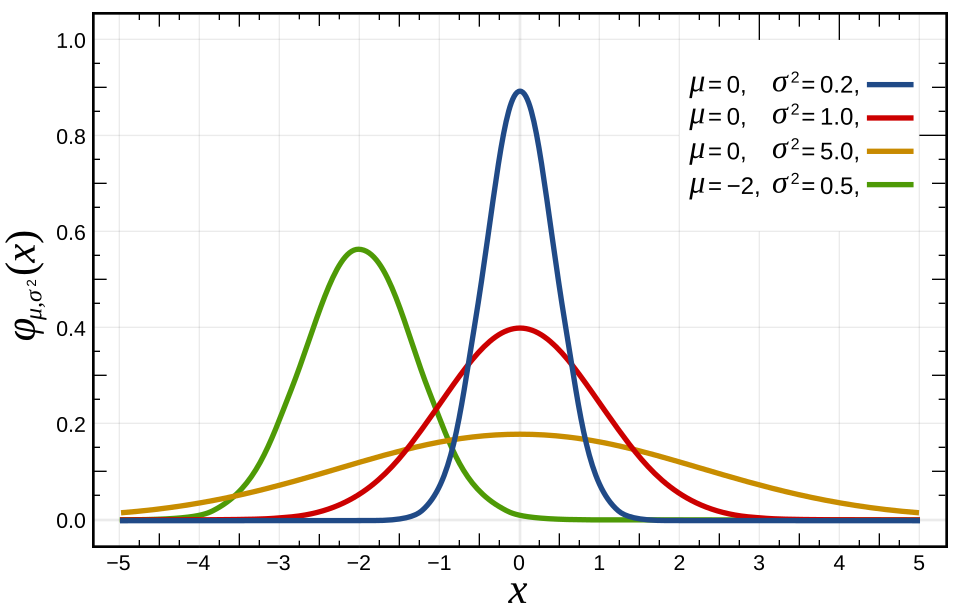

*Image: [Normal Distribution PDF.svg](https://commons.wikimedia.org/wiki/File:Normal_Distribution_PDF.svg) ? Inductiveload; Public domain.*


**What this image shows:** At the same mean, larger variance makes the normal curve wider and lower. Standard deviation is the square root of the variance shown in the legend. For comparison, $[4,4,5,6,6]$ and $[1,1,5,9,9]$ both average 5, but their sample variances are 1 and 16, and their standard deviations are 1 and 4.


### Module 1: Step 1 — Percentiles, Quartiles & 5-Number Summary (Calculated)
Using our sorted salaries: `$3,000, $3,200, $4,000, $4,500, $4,800, $5,000, $5,500, $6,000, $7,000, $12,000`:

1. **Percentiles**
   * **Definition:** A cutoff showing where a value sits in sorted data; the 90th percentile has roughly 90% of values at or below it.
   * **Where we use it:** Exam rankings, salary comparisons, or delivery-time targets.
   * **Why we use it:** To understand relative position rather than just the raw value.
   * **Formula:** One common method uses linear interpolation (finding a value between two neighboring observations). Its position formula is: $\text{Index} = \frac{P}{100} \times (n-1)$
   * **Real Example:** The 90th percentile index $= 0.90 \times 9 = 8.1$ (between index 8 [\$7,000] and index 9 [\$12,000]). Here $P=90$, $n=10$, and positions start at index 0. Move 0.1 of the gap from \$7,000 toward \$12,000: $7000 + 0.1(12000 - 7000) =$ **\$7,500**.
   * **Method note:** Percentile methods can differ in small datasets. The quartiles below use the median-of-halves method from the IQR example. Applying this interpolation method to Q1 and Q3 would instead give \$4,125 and \$5,875; use one method consistently within a calculation.

2. **Quartiles**
   * **Definition:** Three cutoffs that divide sorted data into four roughly equal parts: Q1 at 25%, Q2 at 50%, and Q3 at 75%.
   * **Where we use it:** Calculating IQR and summarizing data with box plots.
   * **Why we use it:** To locate the lower quarter, middle, and upper quarter of the data.
   * **Q1 (25th Percentile):** **\$4,000**
   * **Q2 (50th Percentile / Median):** **\$4,900**
   * **Q3 (75th Percentile):** **\$6,000**

3. **Deciles**
   * **Definition:** Nine cutoffs that divide sorted data into ten roughly equal parts, each representing 10%.
   * **Where we use it:** Grouping exam results or incomes into tenths.
   * **Why we use it:** To compare positions in more detail than quartiles provide.
   * **Calculation:** Using the interpolation method above, the 1st decile is the 10th percentile: index $0.1(9)=0.9$, so $3000 + 0.9(3200-3000) =$ **\$3,180**. The 2nd is the 20th percentile: index $1.8$, so $3200 + 0.8(4000-3200) =$ **\$3,840**.
   * **Meaning:** These are cutoffs for roughly the lowest 10% and 20%; a cutoff need not be an actual salary in the dataset.

4. **The 5-Number Summary**
   * **Definition:** Five values summarizing sorted data: minimum, Q1, median, Q3, and maximum.
   * **Where we use it:** Getting a compact overview of a numerical column and understanding box plots.
   * **Why we use it:** To see the center, the middle spread, and both extremes together.
   * **Minimum:** **\$3,000**
   * **Q1:** **\$4,000**
   * **Median:** **\$4,900**
   * **Q3:** **\$6,000**
   * **Maximum:** **\$12,000**
   * *Visual Application:* These five values summarize the data. A common box plot draws its box from Q1 to Q3 and marks the median. Its whiskers usually stop at the most extreme observations within $1.5 \times \text{IQR}$ of the box, so they need not reach the minimum and maximum; observations beyond them are shown separately.

#### Visual Example ? Quartiles and the Middle 50%

The image connects a box plot with a normal-distribution curve. Q1 and Q3 enclose the middle 50%; their distance is the IQR. Its axis is in standard-deviation units, not dollars.


**Quartiles, the IQR, and the normal-distribution curve**

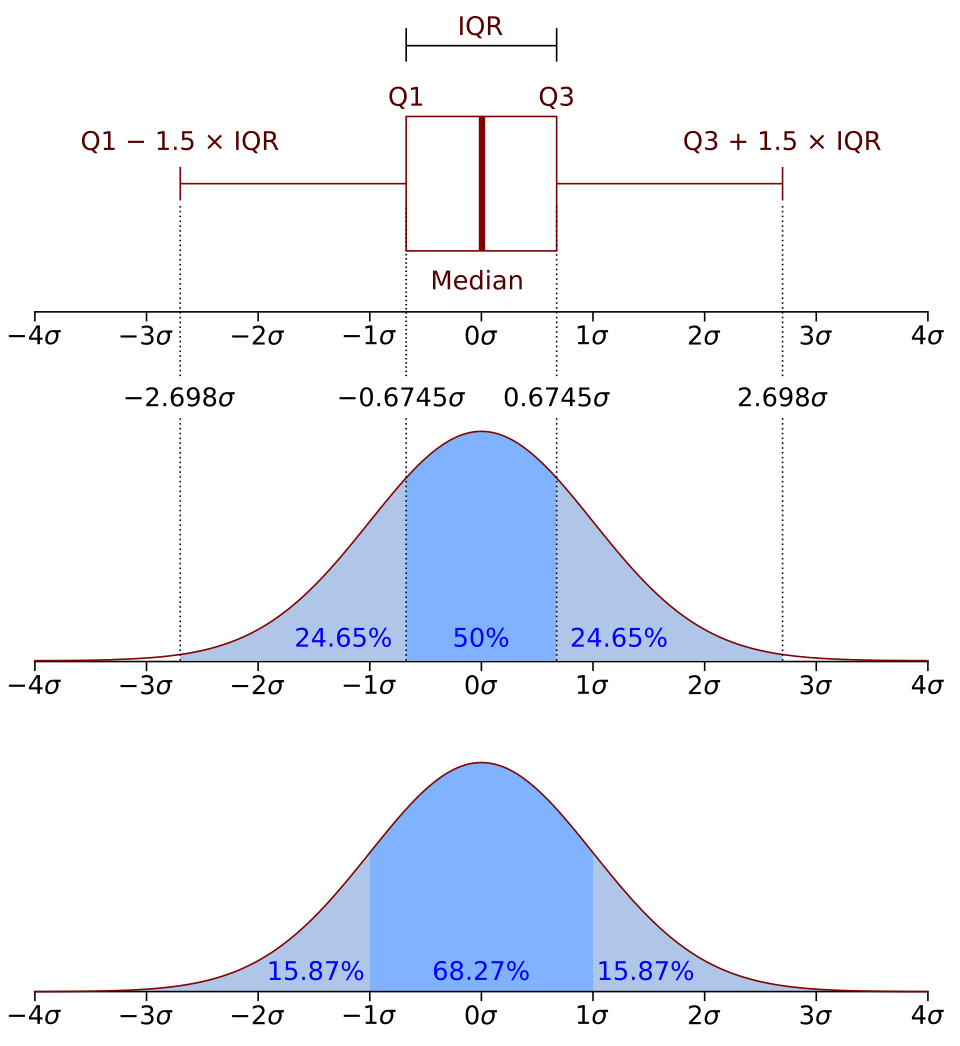

*Image: [Boxplot vs PDF.svg](https://commons.wikimedia.org/wiki/File:Boxplot_vs_PDF.svg) ? Original uploader was Jhguch at en.wikipedia; Derivative work: Chen-Pan Liao (talk).; [CC BY-SA 2.5](https://creativecommons.org/licenses/by-sa/2.5).*


**What this image shows:** The central box covers the middle 50%, whereas the lower curve shows about 68.27% within one standard deviation. These are different intervals. The outer lines labeled $Q1-1.5\,IQR$ and $Q3+1.5\,IQR$ mark fences; an actual sample's whiskers stop at observations within those fences.

For our salary example, Q1 = \$4,000, median = \$4,900, and Q3 = \$6,000 using the median-of-halves convention. The upper fence is \$9,000, so the upper whisker stops at \$7,000 and the \$12,000 salary is plotted separately.


### Module 1: Step 1 — Qualitative Data (Nominal vs. Ordinal)

* **What is it?** Data that describes categories or labels; numeric category codes are still labels.
* **Why we use it:** To group our data so we know how to prepare it for machine learning later.

#### The Two Types:

1. **Nominal (No Order)**
   * **Definition:** Data grouped into named categories with no natural order or ranking.
   * **Where we use it:** Categories such as departments, blood groups, or cities.
   * **Why we use it:** To group records and compare them, such as counting employees in each department.
   * **Real Example:** `Department` (Sales, HR, R&D). Sales is not higher or lower than HR; they are just different names.

2. **Ordinal (Ordered)**
   * **Definition:** Data grouped into categories that have a meaningful order, but whose gaps are not measured.
   * **Where we use it:** Performance ratings, satisfaction levels, or education levels.
   * **Why we use it:** To compare levels, such as Low, Medium, and High, without assuming equal gaps between them.
   * **Real Example:** `Performance Rating` (Low, Medium, High). Medium is higher than Low, and High is higher than Medium.

### Module 1: Step 1 — Quantitative Data (Discrete vs. Continuous)

* **What is it?** Numerical data that represents measurable quantities.
* **Why we use it:** To perform mathematical operations like addition, subtraction, and averaging.

#### The Two Types:

1. **Discrete (Countable)**
   * **Definition:** Numerical data with separate, countable possible values, such as the number of employees.
   * **Where we use it:** Counts of employees, purchases, or completed years of service.
   * **Why we use it:** To record how many items or completed units there are.
   * **Real Example:** `Years at Company` is recorded here in whole years: 1, 2, or 5. Actual tenure can be 5.43 years; an employee count cannot be 5.43.

2. **Continuous (Measurable)**
   * **Definition:** Numerical data modeled as taking any value within a range, including values between whole numbers.
   * **Where we use it:** Measurements such as height, weight, or elapsed time; salary is often treated this way in analysis.
   * **Why we use it:** To describe measured amounts without restricting them to whole units.
   * **Real Example:** `Monthly Salary` (e.g., \$4500.50, \$5120.75) is often treated as continuous in analysis, although payments in cents have discrete increments. Height and elapsed time are clearer continuous measurements.

### Module 1: Step 1 — Central Tendency

* **What is it?** Summarizing the center or typical value of a dataset; different measures answer different questions.
* **Why we use it:** To summarize an entire column of numbers with just one typical value.

#### The Concepts:

1. **Mean (Arithmetic Average)**
   * **Definition:** An average found by sharing the total equally among all observations.
   * **Where we use it:** Average salaries, marks, or daily sales.
   * **Why we use it:** To summarize the overall level using every value; unusually large or small values can pull it up or down.
   * **Real Example:** For 3 salaries (\$3,000, \$4,000, \$20,000), Mean = $(3000 + 4000 + 20000) / 3 = 9000$, or **\$9,000**.

2. **Median (Physical Middle)**
   * **Definition:** The middle value after sorting the data; with an even count, average the two middle values.
   * **Where we use it:** Typical salaries or house prices when a few values are unusually high or low.
   * **Why we use it:** To describe the center without letting extreme values pull it as strongly as they pull the mean.
   * **Real Example:** Sorted salaries (\$3,000, \$4,000, \$20,000). The Median is **\$4,000** (the high \$20,000 salary does not pull this middle value upward).

3. **Mode (Most Frequent)**
   * **Definition:** The value or category that appears most often; more than one can tie for first place.
   * **Where we use it:** The most common rating, product size, or department.
   * **Why we use it:** To identify the most frequent choice, including categories that cannot be averaged.
   * **Real Example:** Feedback ratings: [Good, Good, Excellent]. The Mode is **Good**.

4. **Trimmed Mean (Outlier-Resistant)**
   * **Definition:** An average calculated after removing a chosen percentage of the smallest and largest values.
   * **Where we use it:** Salary or measurement data containing a few extreme values.
   * **Why we use it:** To reduce the influence of extremes while still averaging the remaining values.
   * **Real Example:** Discarding the top 5% and bottom 5% of salaries to remove extreme executive pay and unpaid interns before averaging.

5. **Geometric Mean**
   * **Definition:** An average for values that multiply together, such as growth factors over several years.
   * **Where we use it:** Compound growth of salary, revenue, or investments.
   * **Why we use it:** To find one steady growth factor that produces the same total growth.
   * **Real Example:** For company revenue growth, use positive growth factors. Growth of 10% and 20% gives factors 1.10 and 1.20: $\sqrt{1.10 \times 1.20} - 1 \approx 14.9\%$ average annual growth.

6. **Harmonic Mean**
   * **Definition:** An average for rates when each rate applies to an equal amount of the quantity being measured, such as equal travel distances.
   * **Where we use it:** Average speeds over equal distances or costs per hire when equal budgets are spent.
   * **Why we use it:** To account for slower rates taking more time, or lower costs buying more units; an ordinary mean can give the wrong result.
   * **Real Example:** Traveling equal distances at 30 and 60 km/h gives $2/(1/30+1/60)=40$ km/h. Harmonic means also appear in some financial-ratio averages, such as price-to-earnings; the appropriate weights depend on what is held equal.

### Module 1: Step 1 — Measures of Dispersion

* **What is it?** Measuring how spread out or varied your data points are from the middle.
* **Why we use it:** To understand the consistency or risk in our data (e.g., whether everyone gets paid similar amounts or wildly different amounts).

#### The Concepts:

1. **Range**
   * **Definition:** The distance between the smallest and largest values in a dataset.
   * **Where we use it:** A quick check of the full spread of salaries, marks, or temperatures.
   * **Why we use it:** To see how far apart the two extremes are, although a single extreme value can greatly change it.
   * **Real Example:** Max Salary (\$10,000) - Min Salary (\$2,000) = Range (\$8,000).

2. **Variance**
   * **Definition:** A measure of spread based on squared distances from the mean; larger variance means greater spread.
   * **Where we use it:** Measuring variability and calculations used in statistics and machine learning.
   * **Why we use it:** To combine all deviations into one measure without positive and negative differences canceling out.
   * **Why squared?** To prevent positive and negative differences from canceling each other out.

3. **Standard Deviation (SD)**
   * **Definition:** A measure of spread around the mean, expressed in the same units as the original data.
   * **Where we use it:** Describing variation in salaries, test scores, or measurements.
   * **Why we use it:** To make spread easier to interpret than variance, whose units are squared.
   * **Real Example:** With a mean salary of \$5,000 and an SD of \$1,000, the interval \$4,000 to \$6,000 is one SD on either side of the mean. About 68% fall in this interval **if salaries follow a normal distribution**; mean and SD alone do not guarantee this.

4. **Interquartile Range (IQR)**
   * **Definition:** The spread of the middle 50% of sorted data, leaving out the lowest 25% and highest 25%.
   * **Where we use it:** Studying salary, house-price, or exam-score spread, especially when extreme values are present.
   * **Why we use it:** To focus on the central values so a very high or low value does not dominate the spread.
   * **Real Example:** For Q1 = \$4,000 and Q3 = \$6,000, IQR = \$2,000. Changing only the highest salary does not change these quartiles.

5. **Mean Absolute Deviation (MAD)**
   * **Definition:** The average distance of values from the mean, ignoring whether each difference is positive or negative.
   * **Where we use it:** Describing how far salaries or measurements are from their average.
   * **Why we use it:** To express average distance in the original units without squaring the differences.
   * **Real Example:** If salaries differ from their mean by -\$100, \$0, and +\$100, their absolute distances are \$100, \$0, and \$100. MAD = \$200/3, or about \$66.67. This is mean absolute deviation, not median absolute deviation.

6. **Coefficient of Variation (CV)**
   * **Definition:** The standard deviation relative to the mean, often expressed as a percentage.
   * **Where we use it:** Comparing relative variation in positive quantities with meaningful zero points, such as salary or product weight.
   * **Why we use it:** To compare consistency when datasets have different average sizes.
   * **Real Example:** A group with mean \$5,000 and SD \$500 has CV = 10%; another with mean \$10,000 and SD \$2,000 has CV = 20%. The second group varies more relative to its mean. Converting the same salaries from USD to EUR at one fixed exchange rate leaves CV unchanged.

### Module 1: Step 1 — Percentiles, Quartiles, Deciles & 5-Number Summary

* **What is it?** Using cutoffs in sorted data to describe relative position and spread.
* **Why we use it:** To find where a specific data point stands compared to the rest of the group.

#### The Concepts:

1. **Percentiles**
   * **Definition:** A cutoff showing where a value sits in sorted data; the 90th percentile has roughly 90% of values at or below it.
   * **Where we use it:** Exam rankings, salary comparisons, or delivery-time targets.
   * **Why we use it:** To understand relative position rather than just the raw value.
   * **Real Example:** A score at the 90th percentile means roughly 90% of scores are at or below it; ties and the calculation method affect the exact interpretation.

2. **Quartiles**
   * **Definition:** Three cutoffs that divide sorted data into four roughly equal parts: Q1 at 25%, Q2 at 50%, and Q3 at 75%.
   * **Where we use it:** Calculating IQR and summarizing data with box plots.
   * **Why we use it:** To locate the lower quarter, middle, and upper quarter of the data.

3. **Deciles**
   * **Definition:** Nine cutoffs that divide sorted data into ten roughly equal parts, each representing 10%.
   * **Where we use it:** Grouping exam results or incomes into tenths.
   * **Why we use it:** To compare positions in more detail than quartiles provide.

4. **5-Number Summary**
   * **Definition:** Five values summarizing sorted data: minimum, Q1, median, Q3, and maximum.
   * **Where we use it:** Getting a compact overview of a numerical column and understanding box plots.
   * **Why we use it:** To see the center, the middle spread, and both extremes together.
     1. **Minimum** (Lowest value in the dataset, including any outliers)
     2. **Q1** (25th percentile)
     3. **Median** (50th percentile)
     4. **Q3** (75th percentile)
     5. **Maximum** (Highest value in the dataset, including any outliers)
   * **Box-plot note:** Whisker endpoints may differ from the minimum and maximum because a common box plot shows potential outliers as separate points.

### Module 1: Step 2 — Probability Foundations and Parameters

- **Probability:** A number from 0 to 1 describing how likely an event is. A probability of 0.25 means 25%, not a guarantee of exactly one occurrence in every four trials.
- **Random variable:** A numerical outcome, such as the number of accepted job offers. A discrete variable has countable possible values; a continuous model describes values over a range.
- **Support:** The values a random variable can take. A count cannot be negative; an exponential waiting time cannot be negative.
- **Parameter:** A number controlling a distribution’s behavior. A normal distribution uses mean $\mu$ and standard deviation $\sigma$; a Bernoulli distribution uses success probability $p$.

#### Expected Value and Variance of a Distribution

- **Definition:** Expected value $E[X]$ is the probability-weighted average outcome. Variance measures spread around that expected value.
- **Where we use them:** Summarizing the center and variability of a probability model.
- **Why we use them:** To compare likely outcomes and variation before observing a particular sample.
- **Discrete formulas:** $E[X]=\sum_x xP(X=x)$ and $\operatorname{Var}(X)=\sum_x(x-E[X])^2P(X=x)$. The sum means add over every possible outcome.
- **Example:** For a Bernoulli variable with $p=0.3$, $E[X]=0(0.7)+1(0.3)=0.3$ and variance is $0.7(0-0.3)^2+0.3(1-0.3)^2=0.21$.
- **Meaning:** A long-run average of 0.3 is possible even though each individual outcome is only 0 or 1. For continuous models, areas under a density take the place of sums over individual outcomes.


### Module 1: Step 2 — Probability Functions (PMF, PDF, CDF)

A probability distribution describes which outcomes are possible and how likely they are. A random variable, written $X$, is the numerical outcome being studied.

#### PMF — Probability Mass Function

- **Definition:** A rule giving the probability of each possible value of a discrete variable.
- **Where we use it:** Counts, such as the number of children an employee has.
- **Why we use it:** To answer an exact-value question.
- **Example:** $P(X=2)=0.15$ means a 15% chance of exactly two children. All PMF probabilities add to 1.

#### PDF — Probability Density Function

- **Definition:** A curve whose area over an interval gives the probability of a continuous value falling in that interval.
- **Where we use it:** Measurements, or salaries modeled as continuous.
- **Why we use it:** To calculate probabilities for ranges; curve height alone is not probability.
- **Example:** The area between salaries of \$4,000 and \$5,000 gives the probability of that salary range. In a continuous model, one exact value has probability zero.

#### CDF — Cumulative Distribution Function

- **Definition:** The probability of a value being at or below a cutoff: $F(x)=P(X\leq x)$.
- **Where we use it:** Both discrete and continuous variables.
- **Why we use it:** To answer questions such as “How many are at or below this value?”
- **Example:** In our dataset, 6 of 10 salaries are at or below \$5,000, so the empirical CDF there is $6/10=0.60$, or 60%.


#### Visual Comparison — Exact Outcomes, Areas, and Accumulated Probability

| Function | Question answered | Example |
|---|---|---|
| PMF | What is the probability of this exact discrete value? | Fair die: $P(X=3)=1/6$ |
| PDF | What is the probability over this continuous interval? | Uniform from 0 to 10: $P(2\leq X\leq5)=(5-2)/10=0.3$ |
| CDF | What is the probability at or below this cutoff? | Same uniform model: $F(5)=0.5$ |

For any distribution, $P(a<X\leq b)=F(b)-F(a)$. For a continuous model, including the exact endpoints does not change the probability. A PDF integrates to 1 over its whole support; its height can exceed 1 because height is density, not probability.


**PMF of a discrete uniform distribution**

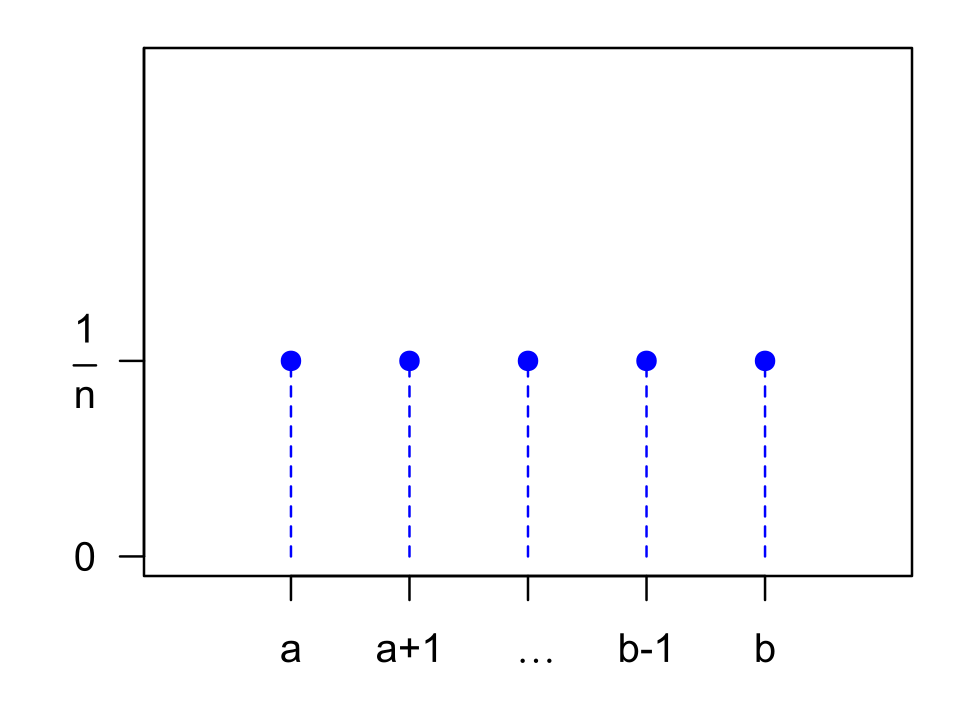

*Image: [Dis Uniform distribution PMF.svg](https://commons.wikimedia.org/wiki/File:Dis_Uniform_distribution_PMF.svg) ? File:Dis Uniform distribution CDF.svg: en:User:Pdbailey, traced by User:Stannered, updated by User:נדב ס derivative work: נדב ס; [CC BY-SA 3.0](http://creativecommons.org/licenses/by-sa/3.0/).*

**CDF for a fair six-sided die**

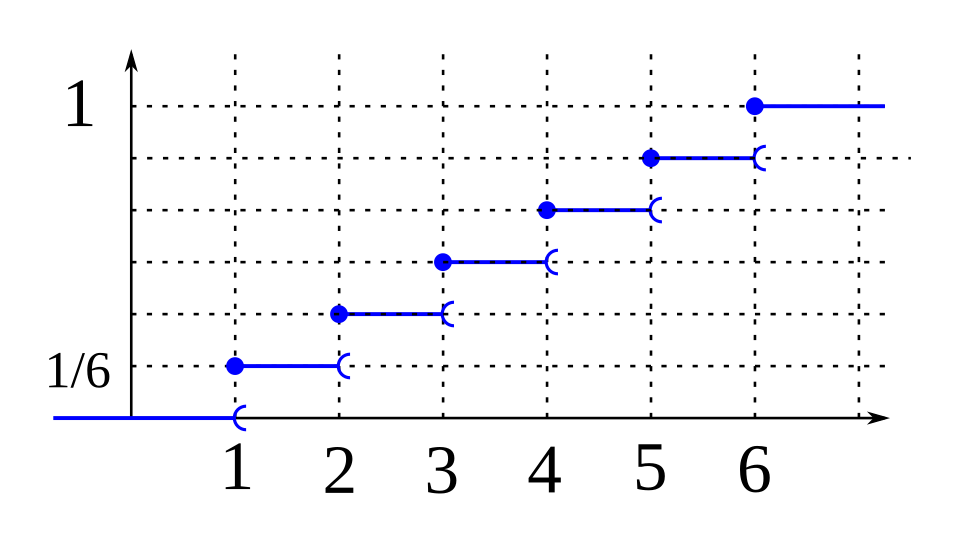

*Image: [Discret uniforme distribution CDF 6.svg](https://commons.wikimedia.org/wiki/File:Discret_uniforme_distribution_CDF_6.svg) ? HB; [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0).*

**PDF of a continuous uniform distribution**



*Image: [Uniform Distribution PDF SVG.svg](https://commons.wikimedia.org/wiki/File:Uniform_Distribution_PDF_SVG.svg) ? IkamusumeFan; [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0).*

**CDF of a continuous uniform distribution**

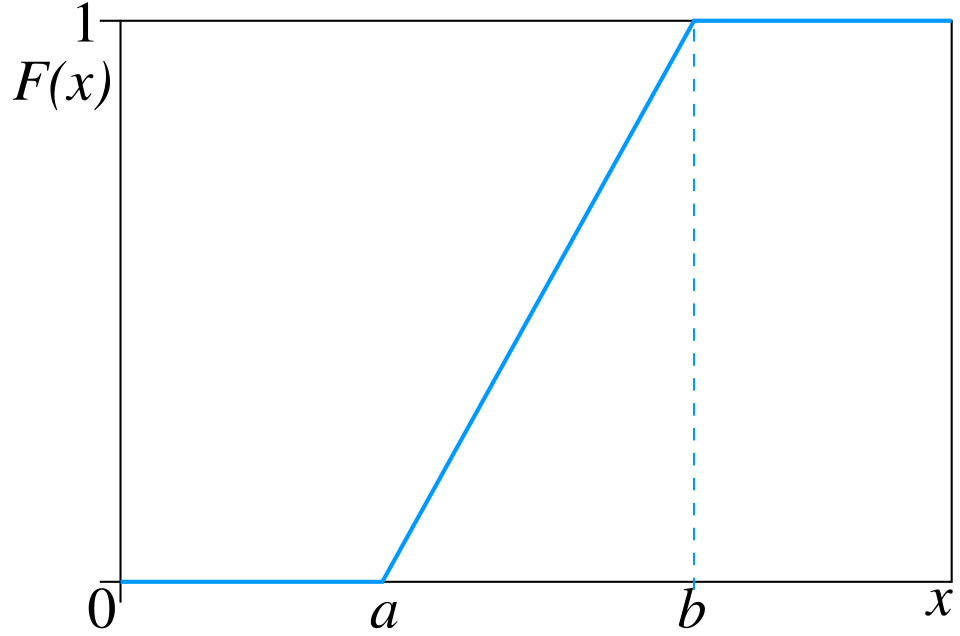

*Image: [Uniform cdf.svg](https://commons.wikimedia.org/wiki/File:Uniform_cdf.svg) ? IkamusumeFan; [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0).*


**What these images show:** The discrete PMF assigns probability to separate values; its six-outcome CDF rises by $1/6$ at each die face. The continuous uniform PDF is flat between $a$ and $b$, with height $1/(b-a)$; its CDF rises from 0 to 1 over the same interval. For $a=0$ and $b=10$, $P(2\leq X\leq5)=(5-2)/10=0.3$, also found from $F(5)-F(2)$.


### Module 1: Step 2 — Normal / Gaussian Distribution

#### Normal distribution

- **Definition:** A symmetric, bell-shaped probability distribution centered on its mean.
- **Where we use it:** Approximate models for measurements such as adult heights within a comparable group, or errors in some statistical models.
- **Why we use it:** It provides a useful model for variation and supports several inference methods when its assumptions fit.
- **Example:** Standard IQ scales are designed around a mean of 100 and a standard deviation of 15; this illustrates the normal model.

**Empirical rule (for a normal distribution):**

- About **68%** lies within 1 standard deviation of the mean: 85–115 in the IQ example.
- About **95%** lies within 2 standard deviations: 70–130.
- About **99.7%** lies within 3 standard deviations: 55–145.

The mean sets the center; standard deviation sets the width. These percentages do not apply to every dataset, and machine learning does not generally require normally distributed input features.


#### Normal Formula, Standard Normal, and Z-Scores

- **Definition:** A Z-score expresses how many standard deviations a value is above or below the mean. The standard normal distribution has mean 0 and standard deviation 1.
- **Where we use it:** Converting normally distributed measurements to a common scale and calculating normal probabilities.
- **Why we use it:** One standard normal CDF can then answer questions for any normal mean and spread.
- **Formula:** $z=(x-\mu)/\sigma$. For an IQ value of 130 with $\mu=100$ and $\sigma=15$, $z=(130-100)/15=2$.
- **Normal PDF:** $f(x)=\frac{1}{\sigma\sqrt{2\pi}}\exp[-\frac12((x-\mu)/\sigma)^2]$, for all real $x$ and $\sigma>0$. Here $\exp(t)=e^t$, $e\approx2.718$, and $\pi\approx3.142$.
- **Probability calculation:** $P(85\leq X\leq115)=\Phi(1)-\Phi(-1)\approx0.8413-0.1587=0.6827$. $\Phi$ is the standard normal CDF.
- **Meaning:** About 68.27% lies in that interval under the normal model. A Z-score can describe non-normal data too, but normal probability rules would not automatically apply.


**Probability areas within standard deviations of a normal mean**



*Image: [Standard deviation diagram.svg](https://commons.wikimedia.org/wiki/File:Standard_deviation_diagram.svg) ? M. W. Toews; [CC BY 2.5](https://creativecommons.org/licenses/by/2.5).*


**What this image shows:** Add the two central 34.1% regions to get approximately 68.2% within one standard deviation. Including the adjacent regions gives approximately 95.4% within two and 99.6% within three; the small discrepancy from 68.27%, 95.45%, and 99.73% comes from rounding the labels. These areas describe a normal model, not every distribution.


### Module 1: Step 2 — Other Standard Distributions

#### Log-Normal

- **Definition:** A distribution of positive values whose natural logarithms follow a normal distribution.
- **Where we use it:** Positive quantities formed by multiplying growth factors; some income or salary datasets can be approximated this way.
- **Why we use it:** To model a long right tail while keeping values positive.
- **Example:** Many salaries may cluster at moderate levels while a few are much higher. That shape alone does not prove a log-normal fit.

#### Uniform

- **Definition:** A distribution with equal probability for each discrete outcome, or equal probability for equal-width intervals in a continuous range.
- **Where we use it:** Fair random choices or random sampling within a fixed range.
- **Why we use it:** To model a situation with no favored outcome or region.
- **Example:** A fair six-sided die has probability $1/6$ for each face.

#### Binomial

- **Definition:** The distribution of the number of successes in a fixed number of independent yes/no trials, each with the same success probability.
- **Where we use it:** Counting accepted offers among 100 applicants under these assumptions.
- **Why we use it:** To estimate how likely different success counts are.
- **Example:** If each applicant independently accepts with probability 0.6, the expected count is $100\times0.6=60$; the actual count can differ.

#### Poisson

- **Definition:** A distribution for event counts in a fixed interval, under a model with independent events and a constant average rate.
- **Where we use it:** Counts such as support tickets per hour when those assumptions are reasonable.
- **Why we use it:** To model how counts vary around an average rate.
- **Example:** If the average is 3 tickets per hour, the rate is $\lambda=3$. An hour can still have 0, 2, 5, or another count.

#### Exponential

- **Definition:** A distribution for the waiting time until the next event in a constant-rate Poisson process.
- **Where we use it:** Time until the next support ticket, under the Poisson-process assumptions.
- **Why we use it:** To estimate the chance of waiting longer than a chosen time.
- **Example:** At 3 tickets per hour, the mean wait is $1/3$ hour, or 20 minutes. Individual waits are not always 20 minutes.

#### Bernoulli

- **Definition:** A distribution for one trial with two outcomes, coded 1 and 0.
- **Where we use it:** Whether one employee leaves (1) or stays (0).
- **Why we use it:** To model one yes/no outcome; a binomial variable counts successes across several such independent trials.
- **Example:** If leaving has probability $p=0.3$, staying has probability $1-p=0.7$.


#### Distribution Formulas and Small Calculations

In these formulas, $p$ is a probability, $n$ a fixed trial count, $k$ an observed success/event count, and $\lambda$ a rate with stated units. The symbol $!$ means factorial: $3!=3\times2\times1=6$, with $0!=1$.

| Distribution | Type and possible values | Parameters | Expected value | Variance |
|---|---|---|---|---|
| Bernoulli | Discrete: 0 or 1 | $0\leq p\leq1$ | $p$ | $p(1-p)$ |
| Binomial | Discrete: $0,1,\ldots,n$ | Integer $n\geq1$, probability $p$ | $np$ | $np(1-p)$ |
| Poisson | Discrete: $0,1,2,\ldots$ | Mean count $\lambda>0$ per stated interval | $\lambda$ | $\lambda$ |
| Uniform | Continuous: $a\leq x\leq b$ | Bounds $a<b$ | $(a+b)/2$ | $(b-a)^2/12$ |
| Exponential | Continuous: $t\geq0$ | Rate $\lambda>0$ per time unit | $1/\lambda$ | $1/\lambda^2$ |
| Normal | Continuous: all real values | Mean $\mu$, SD $\sigma>0$ | $\mu$ | $\sigma^2$ |
| Log-Normal | Continuous: $x>0$ | Mean $\mu$ and SD $\sigma>0$ of $\log X$ | $e^{\mu+\sigma^2/2}$ | $(e^{\sigma^2}-1)e^{2\mu+\sigma^2}$ |

1. **Bernoulli — one yes/no outcome**
   - **PMF:** $P(X=1)=p$ and $P(X=0)=1-p$.
   - **Calculation:** With $p=0.3$, the chance of leaving is 30% and staying is 70%.

2. **Binomial — successes across independent trials with the same $p$**
   - **PMF:** $P(X=k)=\binom nk p^k(1-p)^{n-k}$, where $\binom nk=n!/[k!(n-k)!]$ counts ways to place the successes.
   - **Calculation:** For 5 offers with acceptance probability 0.4, $P(X=2)=10(0.4)^2(0.6)^3=0.3456$.
   - **Meaning:** Exactly two acceptances have probability 34.56%, although the expected count is also 2. Expected count and probability are different quantities.

3. **Poisson — events per interval**
   - **PMF:** $P(X=k)=e^{-\lambda}\lambda^k/k!$.
   - **Calculation:** At a mean of 3 tickets per hour, $P(X=2)=e^{-3}3^2/2!\approx0.2240$.
   - **Meaning:** Exactly two tickets in one hour has probability about 22.40% under this model.

4. **Continuous Uniform — equal-width intervals have equal probability**
   - **PDF:** $f(x)=1/(b-a)$ for $a\leq x\leq b$, and 0 outside.
   - **Calculation:** Between bounds 2 and 6, density is $1/4$. Thus $P(3\leq X\leq5)=(5-3)/4=0.5$.
   - **Meaning:** The interval covers half the allowed range, so it contains half the probability. This is the continuous version; the fair-die example is discrete uniform.

5. **Exponential — wait until the next constant-rate Poisson event**
   - **PDF:** $f(t)=\lambda e^{-\lambda t}$ for $t\geq0$.
   - **CDF:** $P(T\leq t)=1-e^{-\lambda t}$.
   - **Calculation:** With rate 3 tickets per hour, 20 minutes is $1/3$ hour. $P(T\leq1/3)=1-e^{-1}\approx0.6321$.
   - **Meaning:** About 63.21% of waits are at most 20 minutes. The rate and time must use matching units.

6. **Log-Normal — a normal distribution after taking logs**
   - **PDF:** $f(x)=\frac{1}{x\sigma\sqrt{2\pi}}\exp[-(\log x-\mu)^2/(2\sigma^2)]$, for $x>0$.
   - **CDF:** $P(X\leq x)=\Phi((\log x-\mu)/\sigma)$.
   - **Calculation:** With $\mu=0$, $\sigma=1$, $P(X\leq e)=\Phi(1)\approx0.8413$.
   - **Meaning:** About 84.13% lies below 2.718. Here $\mu$ and $\sigma$ describe the logged values, not the original values.


#### Visual Comparison ? Six Probability Models

The first three images show **probability masses at discrete outcomes**. The last three show **continuous densities**. Each legend gives the parameters for its own example; they need not match the numerical examples above.


**Bernoulli PMFs for different success probabilities**

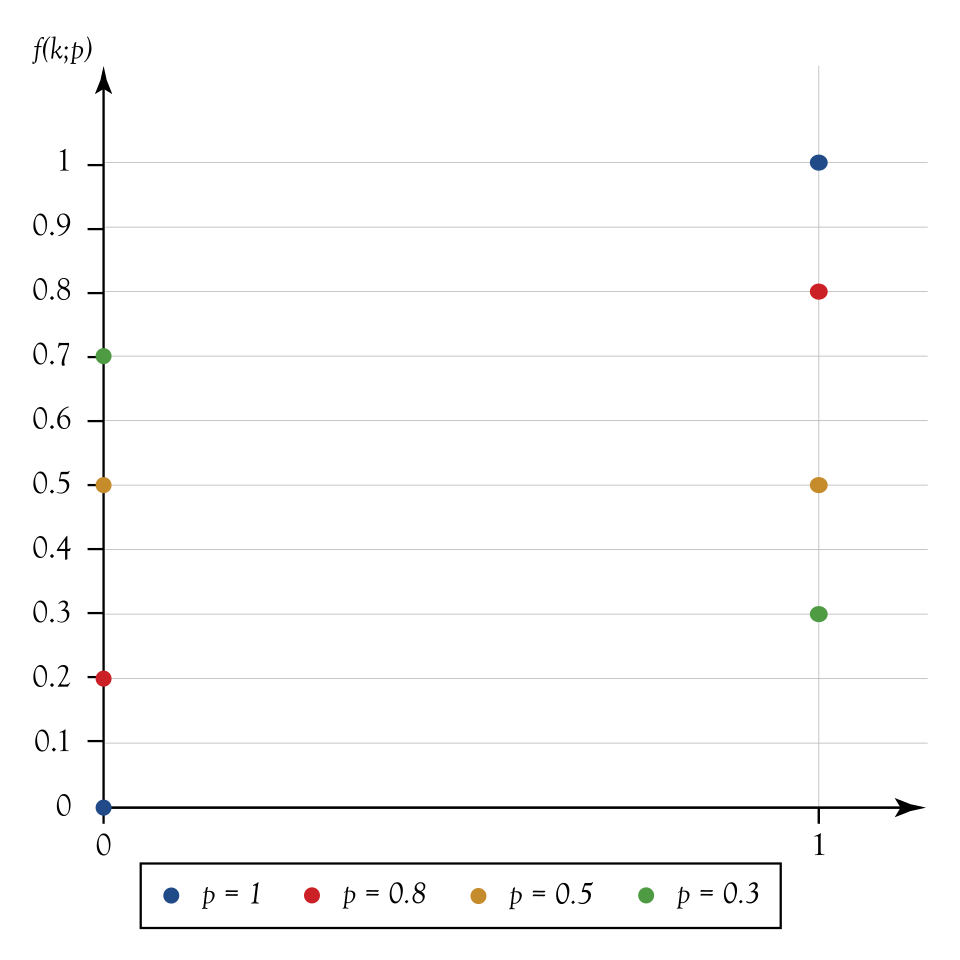

*Image: [Bernoulli distribution PDF.svg](https://commons.wikimedia.org/wiki/File:Bernoulli_distribution_PDF.svg) ? Ederporto; [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0).*

**Binomial PMFs for different trial counts and success probabilities**



*Image: [Binomial distribution pmf.svg](https://commons.wikimedia.org/wiki/File:Binomial_distribution_pmf.svg) ? Tayste; Public domain.*

**Poisson PMFs for different mean counts**

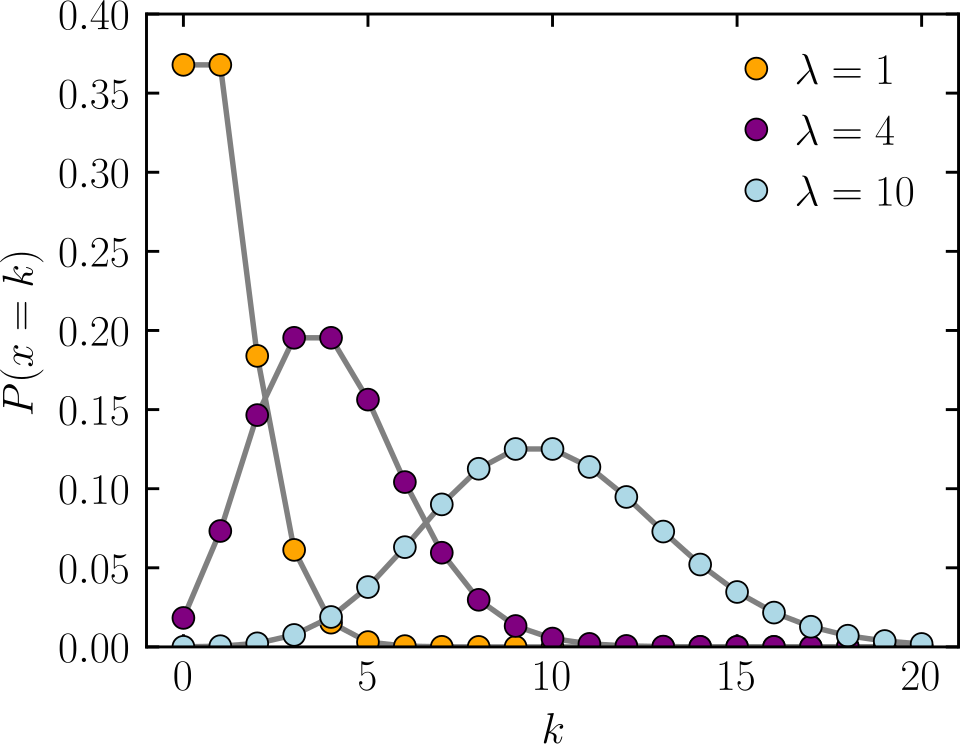

*Image: [Poisson pmf.svg](https://commons.wikimedia.org/wiki/File:Poisson_pmf.svg) ? Skbkekas; [CC BY 3.0](https://creativecommons.org/licenses/by/3.0).*

**Continuous uniform density between a and b**



*Image: [Uniform Distribution PDF SVG.svg](https://commons.wikimedia.org/wiki/File:Uniform_Distribution_PDF_SVG.svg) ? IkamusumeFan; [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0).*

**Exponential densities for different event rates**



*Image: [Exponential probability density.svg](https://commons.wikimedia.org/wiki/File:Exponential_probability_density.svg) ? Newystats; [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0).*

**Log-normal densities for different log-scale spreads**



*Image: [Lognormal distribution PDF.svg](https://commons.wikimedia.org/wiki/File:Lognormal_distribution_PDF.svg) ? Original: PAR Vector: Autopilot; [CC BY-SA 3.0](http://creativecommons.org/licenses/by-sa/3.0/).*


**What these images show:** Bernoulli assigns probability only to 0 and 1. Binomial counts successes in a fixed number of trials; Poisson counts events in an interval. Dots joined by lines in a discrete PMF do not make intermediate values possible. Uniform has constant density within its bounds. A larger exponential rate concentrates waiting times closer to zero. Log-normal values remain positive and can have long right tails.


### Module 1: Step 2 — Shape Metrics (Skewness & Kurtosis)

#### Skewness

- **Definition:** A measure of how unevenly a distribution extends to its left and right.
- **Where we use it:** Salaries, house prices, and other numerical distributions.
- **Why we use it:** To notice when extreme values on one side affect the mean.
- **Positive / right skew:** The right tail extends farther, as with a few very expensive houses. The mean is often above the median.
- **Negative / left skew:** The left tail extends farther. The mean is often below the median. These mean–median patterns are useful tendencies, not universal rules.

#### Kurtosis

- **Definition:** A standardized fourth-moment measure, strongly influenced by extreme values in the tails; it is not simply peak height.
- **Where we use it:** Comparing how strongly extreme observations influence different distributions.
- **Why we use it:** Two distributions can have similar centers and spreads but different behavior in their extremes.
- **Mesokurtic:** Kurtosis 3, matching the normal distribution's kurtosis. This alone does not make a distribution normal.
- **Leptokurtic:** Kurtosis above 3; more influence from extreme values than the normal benchmark.
- **Platykurtic:** Kurtosis below 3; less influence from extreme values than that benchmark.
- **Reading software output:** Excess kurtosis subtracts 3, so its normal benchmark is 0. A sharply peaked shape alone is not enough to determine kurtosis.


#### Skewness and Kurtosis — Formulas and Calculations

**Pearson’s coefficients of skewness** summarize asymmetry through the mean’s position relative to a typical value. Use them for a quick numerical description, rather than relying only on a histogram.

- **First coefficient:** $(\bar x-\text{mode})/s$. It needs a meaningful mode; our salaries are all distinct, so it is not useful here.
- **Second coefficient:** $3(\bar x-\text{median})/s$.
- **Salary calculation:** $3(5500-4900)/2588.01\approx0.696$.
- **Meaning:** The positive result agrees with the high salary pulling the mean above the median. This descriptive coefficient is different from moment-based skewness reported by many libraries.

**Moment-based skewness and kurtosis:** Let $m_r=\frac1n\sum_i(x_i-\bar x)^r$. A moment here is simply an average of powered deviations. The second moment $m_2$ is variance with divisor $n$.

$$g_1=\frac{m_3}{m_2^{3/2}},\qquad b_2=\frac{m_4}{m_2^2},\qquad \text{excess kurtosis}=b_2-3.$$

For the small dataset $[1,2,3,4,5]$, the mean is 3 and deviations are $[-2,-1,0,1,2]$:

- $m_2=(4+1+0+1+4)/5=2$.
- $m_3=(-8-1+0+1+8)/5=0$, so $g_1=0$.
- $m_4=(16+1+0+1+16)/5=6.8$, so $b_2=6.8/2^2=1.7$ and excess kurtosis is $-1.3$.

**Meaning:** This set is symmetric and has lower moment kurtosis than the normal benchmark. Zero skewness alone does not prove symmetry for every distribution. These formulas use direct moments with divisor $n$; software may apply sample-size corrections.

References: [SciPy skewness](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.skew.html) and [SciPy kurtosis](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html).


#### Visual Comparison ? Negative and Positive Skew

The red curves show opposite tail directions. The faint symmetric curves provide a visual reference.


**Negative and positive skewness**

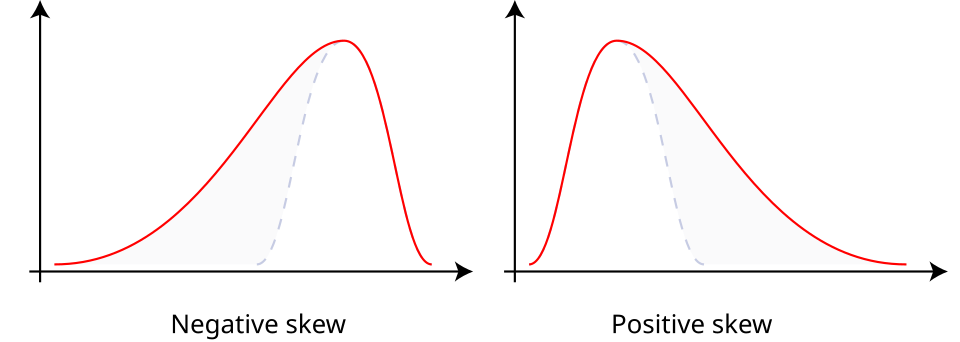

*Image: [Skewness Statistics.svg](https://commons.wikimedia.org/wiki/File:Negative_and_positive_skew_diagrams_(English).svg) ? Rodolfo Hermans (Godot) at en.wikipedia.; [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0).*


**What this image shows:** Negative skew has a longer left tail; positive skew has a longer right tail. Name the skew by its tail, not by the side with the highest peak. The salary example's positive Pearson coefficient is consistent with a longer right tail.


#### Visual Comparison ? Kurtosis and Distribution Shape

These symmetric distributions are standardized to mean 0 and variance 1. The legend reports **excess kurtosis**, which is kurtosis minus 3. Focus on D (double-exponential, also called Laplace), N (normal), and U (uniform).


**Standardized symmetric distributions and their excess kurtosis**



*Image: [Standard symmetric pdfs.svg](https://commons.wikimedia.org/wiki/File:Standard_symmetric_pdfs.svg) ? Original: MarkSweep Vector: Andel; Public domain.*


**What this image shows:** D has excess kurtosis 3 (ordinary kurtosis 6), N has excess 0 (ordinary 3), and U has excess -1.2 (ordinary 1.8). Equal mean and variance do not imply equal shape or behavior in the extremes. Kurtosis depends on the fourth moment; peak height alone does not determine it.

The remaining legend entries are other symmetric comparisons: S = hyperbolic secant, L = logistic, C = raised cosine, and W = Wigner semicircle.


### Module 1: Step 2 — QQ-Plot (Quantile–Quantile Plot)

#### QQ-Plot

- **Definition:** A plot comparing corresponding quantiles of your data and a reference distribution.
- **Where we use it:** Checking whether a numerical variable or model residuals roughly follow a normal or another chosen distribution.
- **Why we use it:** To spot departures in the center or tails before relying on a distributional assumption.
- **Example:** Each point compares the same relative position, such as the 25th percentile, in the two distributions.

**How to read it:**

- Points roughly along a straight line suggest a reasonable match in shape. Real samples rarely line up perfectly.
- Curves or an S-shaped pattern suggest departures, such as skewness or different tails.
- A QQ-plot is visual evidence, not proof; ten observations give limited information.


#### Visual Example ? Reading a Normal QQ-Plot

Both images compare observations against theoretical normal quantiles. The first uses normal data; the second uses right-skewed exponential data. These are illustrative samples, not employee salaries.


**Normal observations compared with normal quantiles**



*Image: [Normal normal qq.svg](https://commons.wikimedia.org/wiki/File:Normal_normal_qq.svg) ? Skbkekas; [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0).*

**Exponential observations compared with normal quantiles**

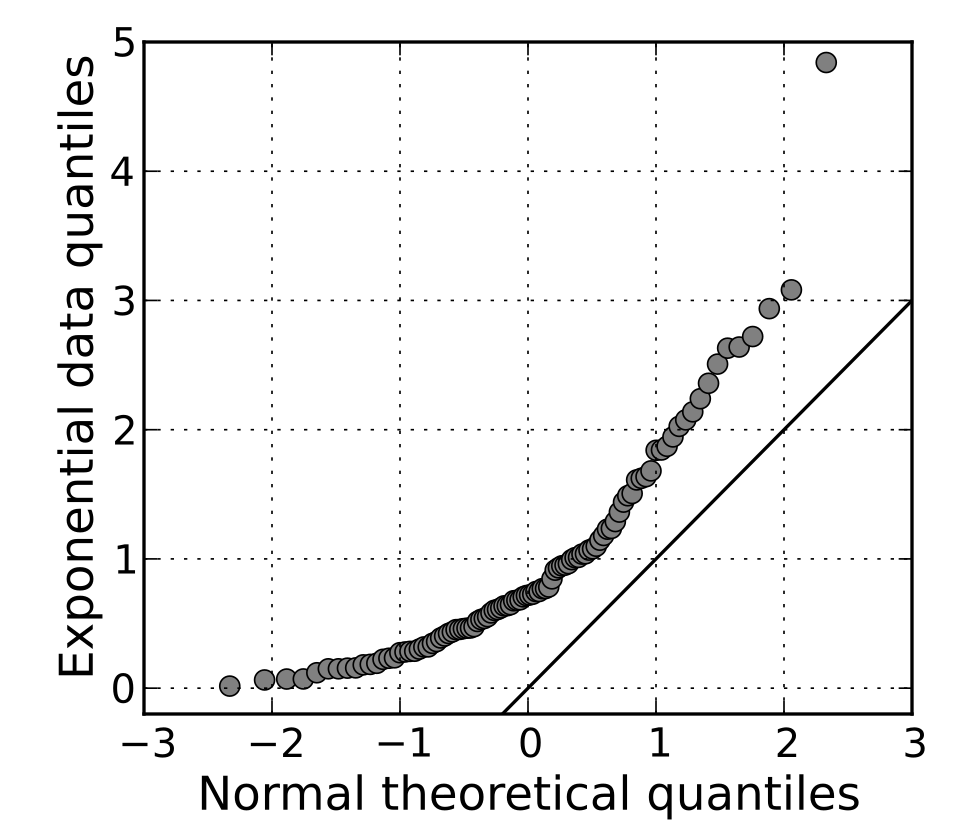

*Image: [Normal exponential qq.svg](https://commons.wikimedia.org/wiki/File:Normal_exponential_qq.svg) ? Skbkekas; [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0).*


**What these images show:** Normal observations lie approximately along the reference line. Exponential observations curve away, especially toward the high end, indicating a poor normal match. A QQ-plot is a visual check rather than proof; the reference line need not have slope 1 when the scales differ.


### Module 1: Step 3 — Covariance (Calculated step-by-step)

- **Definition:** Covariance measures whether two numerical variables tend to move above or below their means together.
- **Where we use it:** Examining tenure and salary, or two other numerical features.
- **Why we use it:** To identify the direction of joint variation; its size depends on the units.
Let's analyze how two numerical variables, `Years at Company` ($X$) and `Monthly Salary` ($Y$), vary together using our **10-Employee Dataset**:

* **Reading its sign:**
  * If positive: As $X$ increases, $Y$ tends to increase.
  * If negative: As $X$ increases, $Y$ tends to decrease.
* **The Formula:**
  $$\text{Cov}(X, Y) = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{n - 1}$$

#### Step-by-Step Calculation:
1. **Find the Means:**
   * Mean of Years $\bar{X} = \frac{1+3+2+5+4+1+8+3+10+3}{10} = \mathbf{4.0}$
   * Mean of Salaries $\bar{Y} = \frac{3000+4500+4000+6000+5500+3200+7000+4800+12000+5000}{10} = \mathbf{5500.0}$

2. **Sum of products of deviations $\sum (X_i - \bar{X})(Y_i - \bar{Y})$:**
   * **Emp 1:** $(1 - 4)(3000 - 5500) = (-3)(-2500) = 7,500$
   * **Emp 2:** $(3 - 4)(4500 - 5500) = (-1)(-1000) = 1,000$
   * **Emp 3:** $(2 - 4)(4000 - 5500) = (-2)(-1500) = 3,000$
   * **Emp 4:** $(5 - 4)(6000 - 5500) = (1)(500) = 500$
   * **Emp 5:** $(4 - 4)(5500 - 5500) = (0)(0) = 0$
   * **Emp 6:** $(1 - 4)(3200 - 5500) = (-3)(-2300) = 6,900$
   * **Emp 7:** $(8 - 4)(7000 - 5500) = (4)(1500) = 6,000$
   * **Emp 8:** $(3 - 4)(4800 - 5500) = (-1)(-700) = 700$
   * **Emp 9:** $(10 - 4)(12000 - 5500) = (6)(6500) = 39,000$
   * **Emp 10:** $(3 - 4)(5000 - 5500) = (-1)(-500) = 500$

3. **Sum the results:**
   $$\text{Sum} = 7500+1000+3000+500+0+6900+6000+700+39000+500 = \mathbf{65,100}$$

4. **Divide by $n - 1$ ($9$):**
   $$\text{Cov}(X, Y) = \frac{65,100}{9} = \mathbf{7,233.33}$$

* **Interpretation:** The covariance is **positive** ($+7,233.33$), showing that, in this sample, as years at the company increase, employee monthly salaries tend to increase. However, because this value is in units of "years $\times$ dollars," a normalized correlation is easier to compare across different units. This association does not establish that tenure causes salary changes.


### Module 1: Step 3 — Pearson Correlation Coefficient ($r$) (Calculated)

- **Definition:** Pearson correlation measures the strength and direction of a linear relationship on a scale from -1 to +1.
- **Where we use it:** Comparing two numerical features, such as tenure and salary.
- **Why we use it:** To put their relationship on a unit-free scale: +1 is a perfect upward line, -1 a perfect downward line, and 0 means no linear correlation.
To solve covariance's scale limitation, we normalize it to standard bounds of $[-1, 1]$:

* **The Formula:**
  $$r = \frac{\text{Cov}(X,Y)}{s_X \times s_Y}$$

#### Step-by-Step Calculation:
1. **Input Variables from our previous calculations:**
   * $\text{Cov}(X, Y) = 7,233.33$
   * Standard Deviation of Years ($s_X$):
     * First, calculate variance of Years ($s_X^2$):
       $$\sum(X_i - \bar{X})^2 = (-3)^2 + (-1)^2 + (-2)^2 + 1^2 + 0^2 + (-3)^2 + 4^2 + (-1)^2 + 6^2 + (-1)^2 = 9+1+4+1+0+9+16+1+36+1 = 78$$
       $$s_X^2 = \frac{78}{9} = 8.67 \rightarrow s_X = \sqrt{8.67} \approx \mathbf{2.94}\text{ years}$$
   * Standard Deviation of Salaries ($s_Y$, the salary spread): $\mathbf{2,588.01}$

2. **Apply the formula:**
   $$r = \frac{7233.33}{2.94 \times 2588.01} = \frac{7233.33}{7608.75} \approx \mathbf{0.95}$$

* **Interpretation:** Pearson's $r \approx \mathbf{0.95}$ indicates an **extremely strong positive linear relationship** between an employee's years at the company and their monthly salary.


### Module 1: Step 3 — Spearman Rank Correlation (Calculated step-by-step)

- **Definition:** Spearman correlation measures how consistently two variables increase or decrease together, using ranks instead of raw values.
- **Where we use it:** Ordered ratings or numerical relationships that move in one direction but need not form a straight line.
- **Why we use it:** To measure monotonic association: as one value increases, the other generally keeps moving in the same direction.
What if the relationship is non-linear but still monotonic? We convert values into positional ranks first:

* **Shortcut formula (only when there are no tied ranks):**
  $$r_s = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$$
  *(where $d_i$ is the difference between ranks of $X$ and $Y$ for employee $i$)*

#### Step-by-Step Calculation:
1. **Rank the values (giving average ranks for ties):**
   * **Years ($X$):** `[1, 3, 2, 5, 4, 1, 8, 3, 10, 3]`
     * Sorted: `1, 1, 2, 3, 3, 3, 4, 5, 8, 10`
     * Ranks assigned:
       * `1` gets rank **1.5** (average of positions 1 and 2).
       * `2` gets rank **3**.
       * `3` gets rank **5** (average of positions 4, 5, and 6).
       * `4` gets rank **7**.
       * `5` gets rank **8**.
       * `8` gets rank **9**.
       * `10` gets rank **10**.
     * **Rank Vector ($R_X$):** `[1.5, 5, 3, 8, 7, 1.5, 9, 5, 10, 5]`

   * **Salary ($Y$):** `[3000, 4500, 4000, 6000, 5500, 3200, 7000, 4800, 12000, 5000]`
     * Sorted: `3000, 3200, 4000, 4500, 4800, 5000, 5500, 6000, 7000, 12000` (no ties!)
     * **Rank Vector ($R_Y$):** `[1, 4, 3, 8, 7, 2, 9, 5, 10, 6]`

2. **Calculate Squared Rank Differences ($d_i^2$):**
   * **Emp 1:** $(1.5 - 1)^2 = 0.25$
   * **Emp 2:** $(5 - 4)^2 = 1.0$
   * **Emp 3:** $(3 - 3)^2 = 0.0$
   * **Emp 4:** $(8 - 8)^2 = 0.0$
   * **Emp 5:** $(7 - 7)^2 = 0.0$
   * **Emp 6:** $(1.5 - 2)^2 = 0.25$
   * **Emp 7:** $(9 - 9)^2 = 0.0$
   * **Emp 8:** $(5 - 5)^2 = 0.0$
   * **Emp 9:** $(10 - 10)^2 = 0.0$
   * **Emp 10:** $(5 - 6)^2 = 1.0$
   * **Sum of $d^2$:** $0.25 + 1.0 + 0 + 0 + 0 + 0.25 + 0 + 0 + 0 + 1.0 = \mathbf{2.5}$

3. **Compute the correlation of the ranks because tenure contains ties:**
   * Both rank means are 5.5. The sums of squared centered ranks are 80 for tenure and 82.5 for salary; the sum of their centered products is 80.
   $$r_s = \frac{\sum(R_{X,i}-\bar R_X)(R_{Y,i}-\bar R_Y)}{\sqrt{\sum(R_{X,i}-\bar R_X)^2\sum(R_{Y,i}-\bar R_Y)^2}}
   = \frac{80}{\sqrt{80\times82.5}} \approx \mathbf{0.9847}$$
   * Here $R$ means rank, the bar means average rank, and $\sum$ means add over the employees.
   * The no-ties shortcut calculation $1-15/990\approx0.9848$ happens to be close, but is not the valid method with these ties.

**Meaning:** Higher tenure almost always accompanies higher salary in this dataset. This is association, not proof of causation.

Reference: [SciPy Spearman correlation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html).


#### Visual Comparison ? Correlation and Scatter-Plot Shape

The numbers above the plots are Pearson correlation coefficients. Compare the direction and tightness of the point patterns, then inspect the curved patterns in the bottom row.


**Scatter plots with different Pearson correlation coefficients**

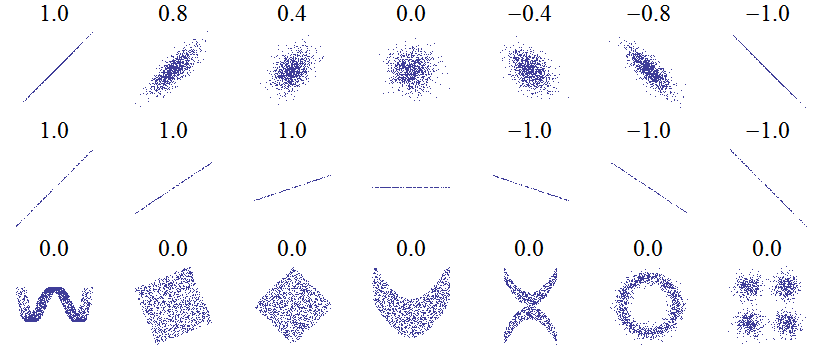

*Image: [Correlation examples.png](https://commons.wikimedia.org/wiki/File:Correlation_examples.png) ? Imagecreator at English Wikipedia; Public domain.*


**What this image shows:** Tight upward and downward straight-line patterns have correlations near +1 and -1. The bottom row contains strong nonlinear patterns with correlations around zero: zero linear correlation does not mean no relationship. Spearman instead compares ranks and can capture a consistently increasing curved relationship. Neither coefficient proves causation.


### Module 1: Step 3 — Categorical Association (Chi-Square & Cramér's V)

#### Chi-square test of independence

- **Definition:** A test comparing observed category counts with the counts expected if two categorical variables were independent.
- **Where we use it:** Questions such as whether performance ratings are associated with department.
- **Why we use it:** To assess evidence of an association between categories that cannot be averaged.

**Observed counts from our dataset:**

| Department | Low | Medium | High | Total |
|---|---:|---:|---:|---:|
| R&D | 1 | 1 | 2 | 4 |
| Sales | 1 | 2 | 1 | 4 |
| HR | 0 | 1 | 1 | 2 |
| Total | 2 | 4 | 4 | 10 |

**Expected count:** $E=(\text{row total}\times\text{column total})/\text{grand total}$.
For R&D–Low, $E=4\times2/10=0.8$, while the observed count $O$ is 1.

**Formula:** $\chi^2=\sum (O-E)^2/E$. Calculate this difference for every table cell, then add: here $\chi^2=1.25$.

**Limit:** All expected counts here are below 5, so the usual large-sample p-value is unreliable. An appropriate exact or permutation method is preferable. Fisher's exact test is a familiar option for a 2×2 table; this table is 3×3 and needs a method supporting that shape.

#### Cramér's V

- **Definition:** A value from 0 to 1 summarizing the strength of association between two categorical variables.
- **Where we use it:** Comparing the size of categorical associations after constructing a contingency table.
- **Why we use it:** Chi-square grows with sample size; V provides a normalized measure.
- **Formula:** $V=\sqrt{\chi^2/[n\min(r-1,c-1)]}$, where $n$ is the number of records and $r,c$ are the table's row and column counts.
- **Calculation:** $V=\sqrt{1.25/(10\times2)}=0.25$.
- **Meaning:** This sample has some observed association. V does not fix the small-sample limitations of the test.

Reference: [SciPy chi-square test and expected counts](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.chi2_contingency.html).


### Module 1: Step 4 — Hypothesis Testing Core Framework & Decision Errors

- **Definition:** Hypothesis testing uses sample data to assess evidence against a stated assumption about a population.
- **Where we use it:** Comparing group means or checking proposed relationships.
- **Why we use it:** To distinguish evidence in the data from differences that sampling variation alone could produce.


#### The Foundations:
1. **Null Hypothesis ($H_0$):** The claim tested, often “no difference” or “no association.” It is assumed for calculating the test result.
   * *Example:* There is no difference in the average monthly salary between employees who stay and those who leave the company ($$\mu_{\text{Stay}} = \mu_{\text{Leave}}$$).
2. **Alternative Hypothesis ($H_1$):** The competing claim specified before looking at the result. Evidence can support it without proving it.
   * *Example:* The average monthly salary of employees who leave differs from that of employees who stay ($$\mu_{\text{Leave}} \neq \mu_{\text{Stay}}$$).
3. **Significance Level ($\alpha$):** The chosen long-run false-positive rate, often 0.05: under the null and the test assumptions, about 5% of repeated tests reject a true null. It is the threshold used to compare the p-value.
4. **p-value:** The probability of obtaining test results at least as extreme as the observed results, assuming that the null hypothesis is completely true.
   * If $p \le \alpha$: Reject $H_0$ (statistically significant).
   * If $p > \alpha$: Fail to reject $H_0$.

#### Decision Errors Matrix:

* **Type I Error (False Positive / $\alpha$):** Rejecting the null hypothesis ($H_0$) when it is actually true.
  * *Corporate Analogy:* Accusing an employee of committing security violations when they are completely innocent.
* **Type II Error (False Negative / $\beta$):** Failing to reject the null hypothesis ($H_0$) when it is actually false.
  * *Corporate Analogy:* Failing to detect an actual security breach committed by a malicious employee.
* **Power of a Test ($1 - \beta$):** The probability of correctly rejecting a false null hypothesis.

**Reading the decision:** A p-value is not the probability that the null hypothesis is true. “Fail to reject” means insufficient evidence against it, not proof that the groups are equal. Here $\mu$ denotes a population mean.

**Errors and power:** Use Type I error to describe a false alarm, Type II error to describe a missed effect, and power to plan how likely a study is to detect a specified effect. The innocent-employee and missed-security-breach examples above illustrate these two error directions.


### Module 1: Step 4 — Parametric Tests: One-Sample and Two-Sample t-Tests (Calculated)

- **Definition:** A t-test compares a mean with a reference value or compares two means, accounting for uncertainty in the sample.
- **Where we use it:** A one-sample test compares our average salary with a benchmark; a two-sample test compares two independent groups.
- **Why we use it:** To judge whether an observed mean difference is large relative to sampling uncertainty.


Let's test if the average salary of our 10 employees is significantly different from a national industry standard average salary of **\$5,000** (using a One-Sample t-Test).

* **Hypotheses:**
  * $H_0: \mu = 5000$
  * $H_1: \mu \neq 5000$

#### Step-by-Step Calculation:
1. **Identify the Sample Metrics:**
   * Sample Mean ($\bar{X}$) = **\$5,500**
   * Sample Standard Deviation ($s$) = **\$2,588**
   * Sample Size ($n$) = **10**

2. **Calculate the Standard Error (SE):**
   $$\text{SE} = \frac{s}{\sqrt{n}} = \frac{2588}{\sqrt{10}} = \frac{2588}{3.162} \approx \mathbf{818.47}$$

3. **Calculate the t-statistic:**
   $$t = \frac{\bar{X} - \mu_0}{\text{SE}} = \frac{5500 - 5000}{818.47} = \frac{500}{818.47} \approx \mathbf{0.611}$$

4. **Determine Degrees of Freedom (df) and Critical Value:**
   * $\text{df} = n - 1 = 9$
   * For a two-tailed test at $\alpha = 0.05$, the critical t-value from standard t-tables is **2.262**.

* **Conclusion:** Since our calculated $|t| = 0.611$ is much smaller than the critical value $2.262$, we **fail to reject the null hypothesis**. There is insufficient evidence of a difference from \$5,000 at the 5% level; this does not prove equality. The tiny sample and high salary outlier also make the normal-population assumption questionable.

**Meaning of the parts:** Standard error describes uncertainty in the estimated mean. The t-statistic counts how many standard errors the observed mean is from the benchmark. Degrees of freedom determine the reference t-distribution; the critical values mark the rejection region. For a small one-sample t-test, independent observations from an approximately normal population are assumed. A two-sample test compares independent group means; Welch’s version allows unequal variances.


### Module 1: Step 4 — ANOVA (Analysis of Variance) (Calculated)

- **Definition:** ANOVA compares group means by weighing differences between groups against variation within them.
- **Where we use it:** Comparing mean salaries across Sales, R&D, and HR.
- **Why we use it:** To test all group means together without running many separate t-tests.

* **Why not use multiple t-tests?** Doing so increases the family-wise error rate (Type I error inflation).

Let's check if the average `Monthly Salary` differs significantly across our three `Departments`: **Sales** (4 employees), **R&D** (4 employees), and **HR** (2 employees).

#### Step-by-Step Calculation:

1. **Group Means and Grand Mean:**
   * **Grand Mean ($\bar{X}_{G}$):** \$5,500
   * **Sales Mean ($\bar{X}_{S}$):** $(3000 + 5500 + 4800 + 5000) / 4 = \mathbf{4575}$
   * **R&D Mean ($\bar{X}_{R}$):** $(4500 + 6000 + 3200 + 12000) / 4 = \mathbf{6425}$
   * **HR Mean ($\bar{X}_{H}$):** $(4000 + 7000) / 2 = \mathbf{5500}$

2. **Sum of Squares Between Groups ($SS_{\text{Between}}$):**
   * Measures how much the group means deviate from the grand mean.
   $$SS_{\text{Between}} = \sum n_j(\bar{X}_j - \bar{X}_G)^2$$
   $$SS_{\text{Between}} = 4(4575 - 5500)^2 + 4(6425 - 5500)^2 + 2(5500 - 5500)^2$$
   $$SS_{\text{Between}} = 4(-925)^2 + 4(925)^2 + 2(0)^2 = 4(855,625) + 4(855,625) = \mathbf{6,845,000}$$

3. **Sum of Squares Within Groups ($SS_{\text{Within}}$):**
   * Measures the variance inside each individual department group.
   * **Sales deviations squared:** $(3000-4575)^2 + (5500-4575)^2 + (4800-4575)^2 + (5000-4575)^2 = 2,480,625 + 855,625 + 50,625 + 180,625 = 3,567,500$
   * **R&D deviations squared:** $(4500-6425)^2 + (6000-6425)^2 + (3200-6425)^2 + (12000-6425)^2 = 3,705,625 + 180,625 + 10,400,625 + 31,080,625 = 45,367,500$
   * **HR deviations squared:** $(4000-5500)^2 + (7000-5500)^2 = 2,250,000 + 2,250,000 = 4,500,000$
   * **Total $SS_{\text{Within}}$:** $3,567,500 + 45,367,500 + 4,500,000 = \mathbf{53,435,000}$

4. **Mean Squares (MS):**
   * **Degrees of Freedom Between ($df_B$):** $k - 1 = 3 - 1 = 2$
   * **Degrees of Freedom Within ($df_W$):** $n - k = 10 - 3 = 7$
   $$MS_{\text{Between}} = \frac{6,845,000}{2} = 3,422,500$$
   $$MS_{\text{Within}} = \frac{53,435,000}{7} \approx 7,633,571.43$$

5. **Calculate the F-Statistic:**
   $$F = \frac{MS_{\text{Between}}}{MS_{\text{Within}}} = \frac{3,422,500}{7,633,571.43} \approx \mathbf{0.448}$$

* **Interpretation:** Because our F-statistic is well below $1.0$ (Critical F-value for $df(2,7)$ is $4.74$), we fail to reject the null hypothesis. This sample does not provide sufficient evidence that the population means differ; it does not establish that they are equal.

**Meaning:** A large F means between-group variation is large relative to within-group variation. Here F is small. This one-way ANOVA assumes independent observations, normally distributed errors within groups, and equal population variances; ten observations and the high salary outlier make conclusions tentative.


### Module 1: Step 4 — Non-Parametric Alternative Tests

These tests avoid the normal-population assumption of some mean-based tests, but still have assumptions. Many use ranks; the KS test compares cumulative distributions. They are not automatic replacements testing exactly the same hypothesis as a t-test.

#### Mann–Whitney U

- **Definition:** A rank-based test comparing two independent groups.
- **Where we use it:** Salary comparisons across two departments when a rank-based question is appropriate.
- **Why we use it:** To assess differences in the distributions without requiring normality.
- **Example:** Often considered alongside an independent two-sample t-test. Interpreting it purely as a median test requires additional shape assumptions.

#### Wilcoxon Signed-Rank

- **Definition:** A test using the ranks and signs of differences within paired observations.
- **Where we use it:** Before-and-after scores from the same employees.
- **Why we use it:** To examine a systematic paired shift without requiring normally distributed differences.
- **Example:** An alternative to the paired t-test when differences are suitably symmetric and their magnitudes can meaningfully be ranked; ordinal labels alone do not guarantee this.

#### Kruskal–Wallis

- **Definition:** A rank-based test comparing several independent groups.
- **Where we use it:** Salary distributions across Sales, R&D, and HR.
- **Why we use it:** To assess group differences without the normality assumption of one-way ANOVA.
- **Example:** A significant result signals a difference somewhere; further comparisons are needed to locate it. A median-only interpretation needs comparable distribution shapes.

#### Kolmogorov–Smirnov (KS)

- **Definition:** A test based on the largest gap between cumulative distribution functions.
- **Where we use it:** Comparing two continuous samples, or a sample with a fully specified reference distribution.
- **Why we use it:** To detect differences in overall distribution, including center and spread.
- **Example:** The ordinary one-sample p-value is not valid unchanged when normal-distribution parameters are estimated from that same sample.


### Module 1: Step 4 — Multicollinearity Diagnostics (VIF)

- **Definition:** Multicollinearity means a predictor is strongly explained by a combination of other predictors.
- **Where we use it:** Regression models with overlapping inputs, such as age and years at a company.
- **Why we use it:** To understand why individual regression coefficients may be unstable or hard to interpret.

* **VIF definition:** The variance inflation factor measures how much overlap with other predictors inflates the variance of an estimated regression coefficient.
* **The Primary Diagnostic:** **Variance Inflation Factor (VIF)**.

#### The Formula:
For a given predictor variable $X_j$, we run a linear regression predicting $X_j$ using all *other* independent variables. Let $R_j^2$ be the coefficient of determination for this auxiliary regression:
$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$

#### How to Interpret VIF Values:
* **VIF = 1:** No linear explanatory power from the other predictors in this auxiliary regression; nonlinear relationships may still exist.
* **1 < VIF < 5:** Some inflation. Whether it matters depends on the modeling goal and data.
* **VIF \ge 5 to 10:** High correlation; structural coefficients may become highly unstable and difficult to interpret.
* **Real Example:** If `Years at Company` and `Age` are both used to predict `Salary`, their overlap may increase VIF. Calculate it rather than assuming it is high.

**Small calculation:** If the other predictors explain 80% of a feature’s variance, $R_j^2=0.8$ and $\text{VIF}=1/(1-0.8)=5$. The coefficient variance is inflated fivefold relative to an orthogonal design with comparable feature variation. Cutoffs of 5 or 10 are guidelines, not universal rules.
